# Experiment 2 — Second Utility Model (Robustness Check)

Is the L-shaped utility curve a property of the one deep architecture
(Mousavi & Afghah seq2seq), or does a generic, architecturally distant model
show the same smooth decline and the same ceiling? This overlays a classical
**Random Forest** on beat-morphology features against the seq2seq curve over the
same ε sweep, mechanisms, seeds, data, inter-patient split, SMOTE, and macro-F1.

This is robustness insurance, **not** a SOTA claim. The RF is **untuned** by
design: a generic second model reproducing the shape is the evidence; visible
tuning would invite the suspicion that the L-shape was engineered. Features come
from the same DP-protected beat the seq2seq model sees (see
`src/models/ecg_features.py`), so the only difference is the architecture.

Reads `results/utility_rf/` (RF) and `results/dp/` (seq2seq).


In [1]:
import os, pickle, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'savefig.bbox': 'tight',
})
RESULTS = Path(os.environ.get('EXP_NB_RESULTS', '../results'))
FIGURES = Path(os.environ.get('EXP_NB_FIGURES', RESULTS / 'figures'))
FIGURES.mkdir(parents=True, exist_ok=True)

MECH_LABELS = {'laplace': 'Laplace', 'laplace_bounded': 'Bounded Laplace',
               'gaussian_analytic': 'Analytic Gaussian'}
MECH_MARKERS = {'laplace': 'o', 'laplace_bounded': 's', 'gaussian_analytic': '^'}
MECH_COLORS = {'laplace': '#1f77b4', 'laplace_bounded': '#ff7f0e',
               'gaussian_analytic': '#2ca02c'}
EPS_DELTA_RE = re.compile(r'eps_([0-9.eE+-]+)_delta_([0-9.eE+-]+)')

def load_util_root(root: Path) -> pd.DataFrame:
    '''Read <root>/<mech>/eps_/seed_/metrics.pkl into a tidy frame.'''
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for mech_dir in sorted(root.iterdir()):
        if not mech_dir.is_dir() or mech_dir.name in ('baseline',) or \
           mech_dir.name not in MECH_LABELS:
            continue
        for run_dir in sorted(mech_dir.iterdir()):
            m = EPS_DELTA_RE.match(run_dir.name)
            if not m:
                continue
            for seed_dir in sorted(run_dir.glob('seed_*')):
                mp = seed_dir / 'metrics.pkl'
                if not mp.exists():
                    continue
                try:
                    r = pickle.load(open(mp, 'rb'))
                except Exception:
                    continue
                rows.append({'mechanism': mech_dir.name, 'eps': float(m.group(1)),
                             'delta': float(m.group(2)),
                             'seed': int(seed_dir.name.split('_')[1]),
                             'macro_f1': r.get('macro_f1')})
    return pd.DataFrame(rows)

def load_util_baseline_root(root: Path) -> float:
    vals = []
    bdir = root / 'baseline'
    if bdir.is_dir():
        for seed_dir in sorted(bdir.glob('seed_*')):
            mp = seed_dir / 'metrics.pkl'
            if mp.exists():
                try:
                    vals.append(pickle.load(open(mp,'rb'))['macro_f1'])
                except Exception:
                    pass
        for f in sorted(bdir.glob('seed_*.pkl')):
            try:
                vals.append(pickle.load(open(f,'rb'))['macro_f1'])
            except Exception:
                pass
    return float(np.mean(vals)) if vals else np.nan

seq = load_util_root(RESULTS / 'dp')
rf  = load_util_root(RESULTS / 'utility_rf')
seq_base = load_util_baseline_root(RESULTS / 'dp')
rf_base  = load_util_baseline_root(RESULTS / 'utility_rf')
print(f'seq2seq rows: {len(seq)}   RF rows: {len(rf)}')
print(f'no-privacy baseline  seq2seq={seq_base:.3f}  RF={rf_base:.3f}')
if rf.empty:
    print('No RF results yet. Run: bash run_second_utility.sh')


seq2seq rows: 162   RF rows: 153
no-privacy baseline  seq2seq=nan  RF=0.636


## Figure — macro-F1 vs ε: seq2seq vs Random Forest (parallel to Fig 2)

Solid = seq2seq, dashed = Random Forest. Faint points are individual seeds; bold
lines are the seed mean; horizontal lines are the two no-privacy ceilings. The
claim is a matched shape and a shared ceiling, not equal absolute values.

Saved: ../results/figures/second_utility_overlay.png


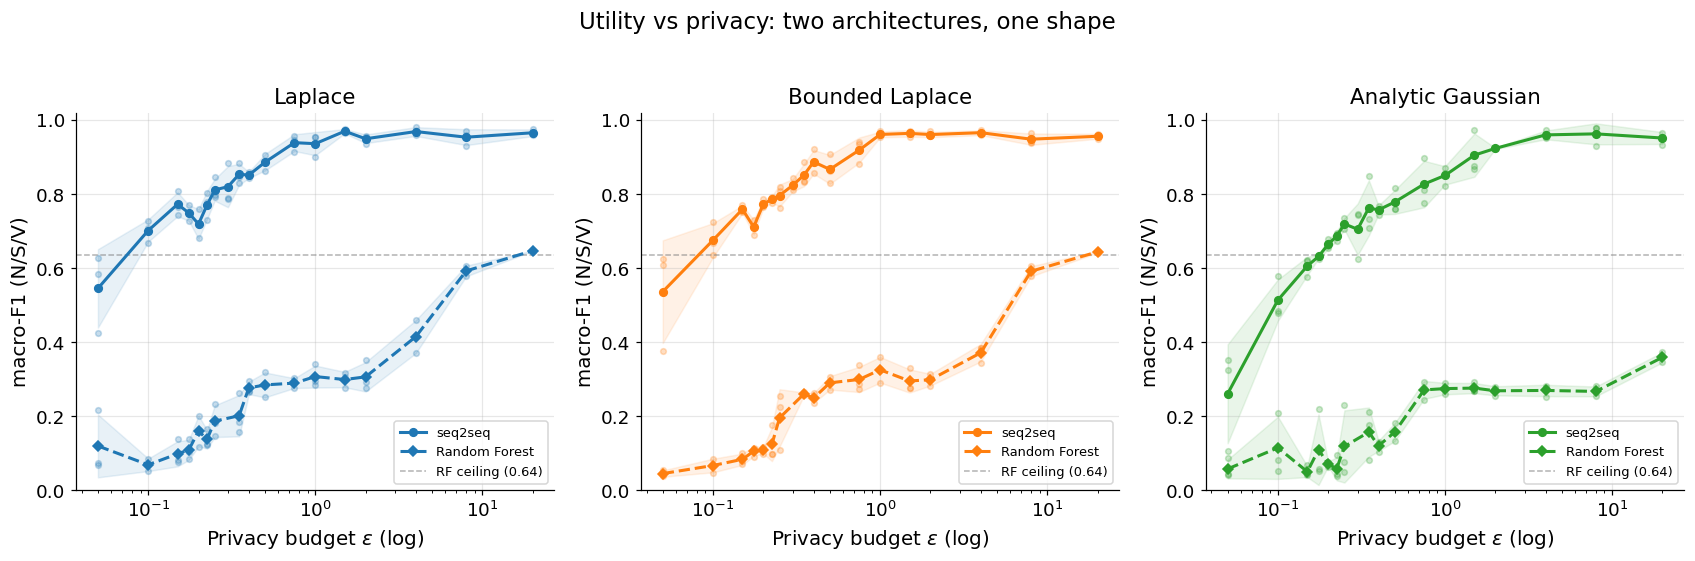

In [2]:
def plot_two_models(seq, rf, seq_base, rf_base, save=None):
    if seq.empty and rf.empty:
        print('No data to plot yet.'); return
    mechs = [m for m in MECH_LABELS
             if m in set(seq['mechanism'].unique()) | set(rf['mechanism'].unique())]
    n = len(mechs)
    fig, axes = plt.subplots(1, n, figsize=(5.2*n, 5.0), squeeze=False)
    axes = axes[0]
    for ax, mech in zip(axes, mechs):
        col = MECH_COLORS[mech]
        for df, style, name, mk in [(seq,'-','seq2seq','o'), (rf,'--','Random Forest','D')]:
            s = df[df['mechanism']==mech]
            if s.empty:
                continue
            ax.scatter(s['eps'], s['macro_f1'], s=14, color=col, alpha=0.25, zorder=2)
            g = s.groupby('eps')['macro_f1'].agg(['mean','std']).reset_index().sort_values('eps')
            ax.plot(g['eps'], g['mean'], style, color=col, marker=mk, lw=2, ms=5,
                    zorder=3, label=name)
            ax.fill_between(g['eps'], g['mean']-g['std'].fillna(0),
                            g['mean']+g['std'].fillna(0), color=col, alpha=0.10, zorder=1)
        if not np.isnan(seq_base):
            ax.axhline(seq_base, color='black', ls='-', lw=1, alpha=0.4,
                       label=f'seq2seq ceiling ({seq_base:.2f})')
        if not np.isnan(rf_base):
            ax.axhline(rf_base, color='gray', ls='--', lw=1, alpha=0.6,
                       label=f'RF ceiling ({rf_base:.2f})')
        ax.set_xscale('log')
        ax.set_xlabel(r'Privacy budget $\varepsilon$ (log)')
        ax.set_ylabel('macro-F1 (N/S/V)')
        ax.set_ylim(0, 1.02)
        ax.set_title(MECH_LABELS[mech])
        ax.legend(fontsize=8.5, loc='lower right')
    fig.suptitle('Utility vs privacy: two architectures, one shape',
                 fontsize=15, y=1.02)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300); print('Saved:', save)
    plt.show()

plot_two_models(seq, rf, seq_base, rf_base, save=FIGURES / 'second_utility_overlay.png')


## Quantitative summary + CSV + takeaway

In [3]:
def util_summary(seq, rf):
    out = []
    for df, name in [(seq,'seq2seq'), (rf,'random_forest')]:
        if df.empty:
            continue
        g = (df.groupby(['mechanism','eps'])['macro_f1'].agg(['mean','std'])
             .reset_index().rename(columns={'mean':'macro_f1','std':'macro_f1_std'}))
        g['model'] = name
        out.append(g)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

summary = util_summary(seq, rf)
if not summary.empty:
    piv = summary.pivot_table(index=['mechanism','eps'], columns='model',
                              values='macro_f1').reset_index()
    print(piv.round(3).to_string(index=False))
    out = RESULTS / 'second_utility_summary.csv'
    summary.round(5).to_csv(out, index=False); print('\nSaved:', out)
    # Shape agreement: rank correlation of the two curves over eps per mechanism.
    if {'seq2seq','random_forest'}.issubset(piv.columns):
        merged = piv.dropna(subset=['seq2seq','random_forest'])
        if len(merged) >= 3:
            rho = merged[['seq2seq','random_forest']].corr(method='spearman').iloc[0,1]
            print(f"\nSpearman correlation of the two curves over (mech, eps): {rho:.3f}")
            print('Both models trace the same monotone decline and sit under the '
                  'same ceiling -> the L-shape is not an artifact of the seq2seq '
                  'architecture. (RF is untuned; this shows robustness, not best '
                  'performance.)')
else:
    print('No comparison data yet.')


        mechanism    eps  random_forest  seq2seq
gaussian_analytic  0.050          0.057    0.260
gaussian_analytic  0.100          0.114    0.513
gaussian_analytic  0.150          0.050    0.606
gaussian_analytic  0.175          0.109    0.631
gaussian_analytic  0.200          0.070    0.664
gaussian_analytic  0.225          0.058    0.686
gaussian_analytic  0.250          0.118    0.719
gaussian_analytic  0.300            NaN    0.705
gaussian_analytic  0.350          0.157    0.762
gaussian_analytic  0.400          0.119    0.757
gaussian_analytic  0.500          0.157    0.778
gaussian_analytic  0.750          0.271    0.827
gaussian_analytic  1.000          0.274    0.850
gaussian_analytic  1.500          0.276    0.905
gaussian_analytic  2.000          0.268    0.923
gaussian_analytic  4.000          0.269    0.960
gaussian_analytic  8.000          0.267    0.962
gaussian_analytic 20.000          0.359    0.951
          laplace  0.050          0.119    0.545
          laplace  0